# BiomedParse Fine-Tuning â€” Peripheral Vascular Ultrasound

Teaches BiomedParse to segment **fascia layers** and **veins** in the specific
peripheral vascular ultrasound frames used by the CHIVA varicose-vein protocol.

**Pipeline**
1. Inspect Task_3 training data
2. Prepare data in BiomedParse format (1024Ã—1024, COCO naming)
3. Generate COCO JSON annotations
4. Launch fine-tuning
5. Inference with the fine-tuned model

## 0 Â· Imports & Paths

In [15]:
import csv
import glob
import json
import os
import sys
import shutil
import collections
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

# â”€â”€ Repo roots â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BASE_DIR       = Path(r"C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection")
BIOMEDPARSE    = BASE_DIR / "BiomedParse"
TASK3_BASE     = Path(r"C:\Users\Krish\Downloads\Cygnus_Med_Demo\Task_3_Experimental"
                      r"\vein_detection_task_3_training")

sys.path.insert(0, str(BASE_DIR / 'stubs'))
sys.path.insert(0, str(BIOMEDPARSE))

# â”€â”€ Dataset constants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FASCIA_CSV = TASK3_BASE / "output/fascia/metadata.csv"
VEIN_CSV   = TASK3_BASE / "output/vein/metadata.csv"
OUT_ROOT   = BIOMEDPARSE / "biomedparse_datasets" / "Fascia_Detection"
IMG_SIZE   = 1024

FASCIA_TEST_VIDEO   = "Knee-Ankle-Seg1"   # held out; different anatomy â†’ cleanest OOD test
VEIN_TEST_FRACTION  = 0.15

print("BASE_DIR   :", BASE_DIR)
print("TASK3_BASE :", TASK3_BASE)
print("OUT_ROOT   :", OUT_ROOT)

BASE_DIR   : C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection
TASK3_BASE : C:\Users\Krish\Downloads\Cygnus_Med_Demo\Task_3_Experimental\vein_detection_task_3_training
OUT_ROOT   : C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection


## 1 Â· Inspect the Training Data

In [16]:
# â”€â”€ Load metadata CSVs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
with open(FASCIA_CSV) as f:
    all_fascia = list(csv.DictReader(f))

with open(VEIN_CSV) as f:
    all_vein = list(csv.DictReader(f))

fascia_rows = [r for r in all_fascia if r['has_fascia'] == 'True' and r['valid_mask'] == 'True']
vein_rows   = [r for r in all_vein   if r['has_vein']   == 'True']

fascia_by_video = collections.Counter(r['video'] for r in fascia_rows)
vein_by_video   = collections.Counter(r['video'] for r in vein_rows)

print(f"Fascia frames (valid): {len(fascia_rows)}")
for v, n in sorted(fascia_by_video.items()): print(f"  {v}: {n}")

print(f"\nVein frames (valid): {len(vein_rows)}")
for v, n in sorted(vein_by_video.items()): print(f"  {v}: {n}")

Fascia frames (valid): 2858
  202207111318_38-Perf: 433
  202207191643_00-Moving: 1387
  Knee-Ankle-Seg1: 79
  sample_data: 959

Vein frames (valid): 2037
  202207111318_38-Perf: 427
  202207191643_00-Moving: 723
  sample_data: 887


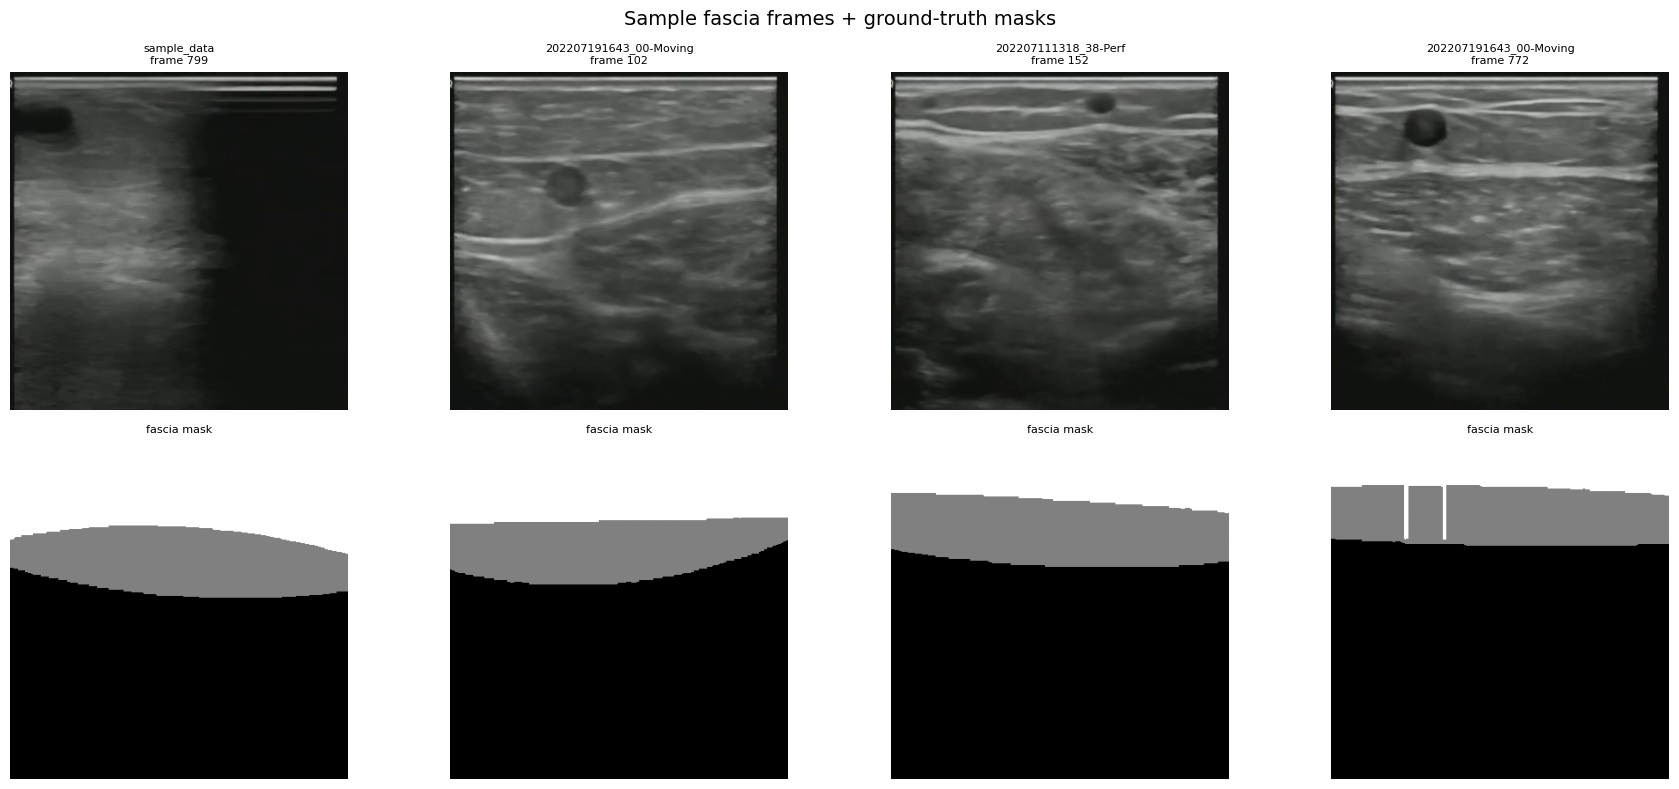

In [17]:
# â”€â”€ Visualise 4 sample fascia frames with their masks â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import random
random.seed(42)
samples = random.sample(fascia_rows, 4)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Sample fascia frames + ground-truth masks", fontsize=14)

for i, row in enumerate(samples):
    fp = TASK3_BASE / row['frame_path']
    mp = TASK3_BASE / row['mask_path']
    img  = np.array(Image.open(fp).convert('RGB'))
    mask = np.array(Image.open(mp).convert('L'))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"{row['video']}\nframe {row['frame_idx']}", fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title("fascia mask", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

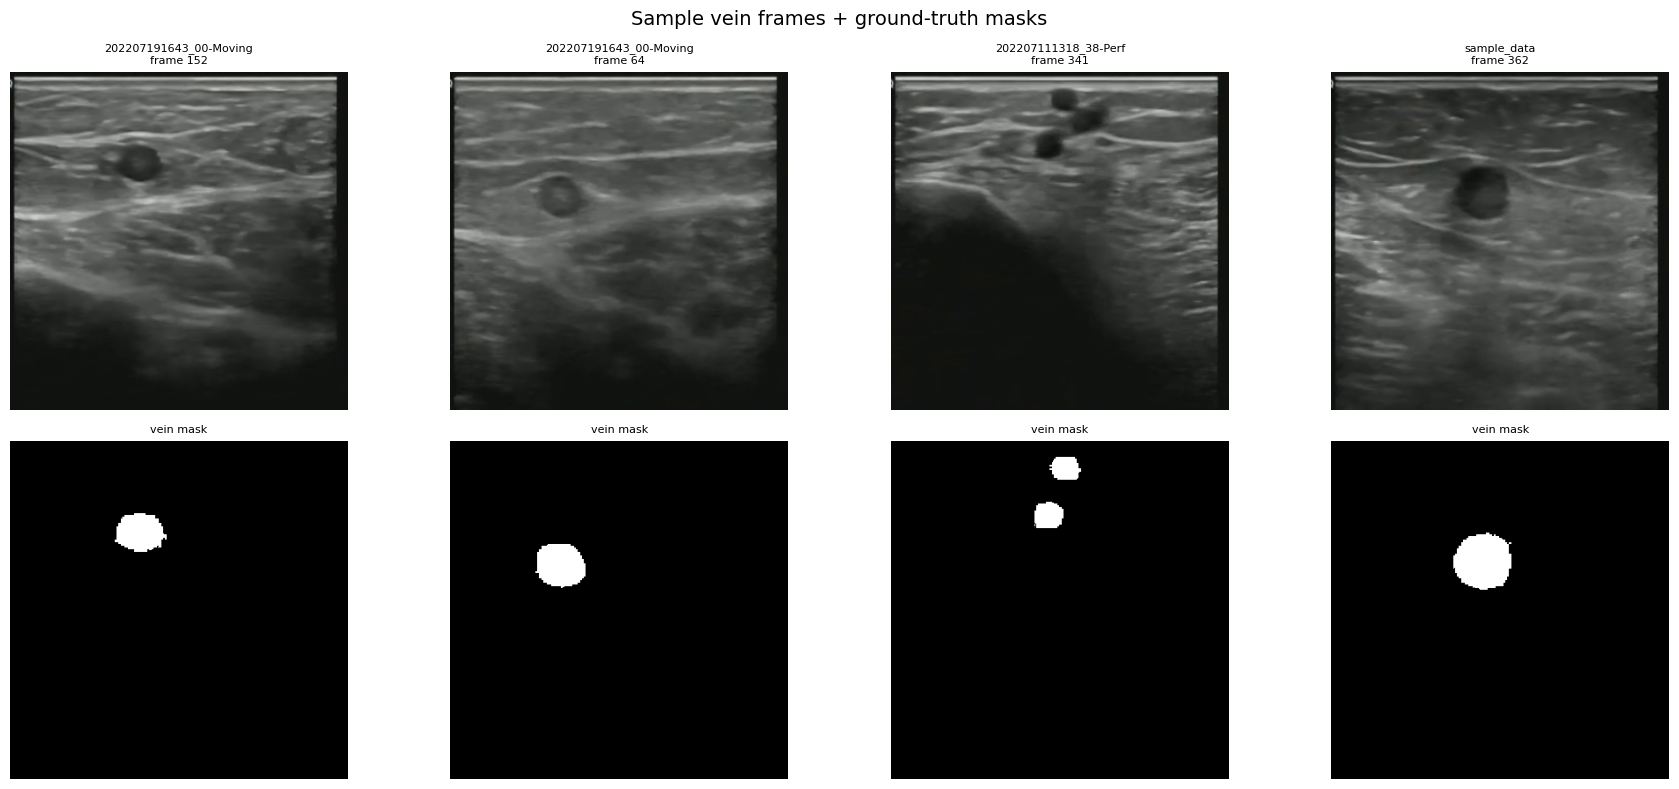

In [18]:
# â”€â”€ Visualise 4 sample vein frames with their masks â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
samples_v = random.sample(vein_rows, 4)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Sample vein frames + ground-truth masks", fontsize=14)

for i, row in enumerate(samples_v):
    fp = TASK3_BASE / row['frame_path']
    mp = TASK3_BASE / row['mask_path']
    img  = np.array(Image.open(fp).convert('RGB'))
    mask = np.array(Image.open(mp).convert('L'))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"{row['video']}\nframe {row['frame_idx']}", fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title("vein mask", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 2 Â· Prepare Data in BiomedParse Format

### File naming convention
| File type | Name pattern |
|-----------|-------------|
| Image | `{id:06d}_Ultrasound_PeripheralVascular.png` |
| Fascia mask | `{id:06d}_Ultrasound_PeripheralVascular_fascia+layer.png` |
| Vein mask | `{id:06d}_Ultrasound_PeripheralVascular_vein.png` |

The `create-customer-datasets.py` script splits the mask filename on `_` and uses the last token (before `.png`) as the class name, replacing `+` with space. So `fascia+layer` â†’ `"fascia layer"` which maps to category ID 17 in `label_base.json`.

### Split strategy
- **Fascia test**: hold out `Knee-Ankle-Seg1` (79 frames â€” different anatomical site, cleanest OOD test)
- **Vein test**: last 15% of each video (temporal holdout)

In [19]:
# â”€â”€ Create output directory structure â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for d in ['train', 'train_mask', 'test', 'test_mask']:
    (OUT_ROOT / d).mkdir(parents=True, exist_ok=True)

print("Output dirs ready:")
for d in ['train', 'train_mask', 'test', 'test_mask']:
    print(f"  {OUT_ROOT / d}")

Output dirs ready:
  C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\train
  C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\train_mask
  C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\test
  C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\test_mask


In [20]:
# â”€â”€ Helper: resize and save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def resize_rgb(path: Path) -> Image.Image:
    img = Image.open(path).convert('RGB')
    return img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC) if img.size != (IMG_SIZE, IMG_SIZE) else img

def resize_mask(path: Path) -> Image.Image:
    mask = Image.open(path).convert('L')
    return mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST) if mask.size != (IMG_SIZE, IMG_SIZE) else mask

# Shared global ID counters per split so fascia + vein share the same ID space
_gid = {'train': 0, 'test': 0}

In [33]:
# â”€â”€ Process fascia â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fascia_train = [r for r in fascia_rows if r['video'] != FASCIA_TEST_VIDEO]
fascia_test  = [r for r in fascia_rows if r['video'] == FASCIA_TEST_VIDEO]
print(f"Fascia  train={len(fascia_train)}  test={len(fascia_test)}")

fascia_frame_gid = {}   # (split, frame_path_str) â†’ gid

for split, rows in [('train', fascia_train), ('test', fascia_test)]:
    for row in tqdm(rows, desc=f'fascia {split}'):
        fp  = TASK3_BASE / row['frame_path']
        mp  = TASK3_BASE / row['mask_path']
        key = (split, row['frame_path'])

        if key not in fascia_frame_gid:
            gid = _gid[split]; _gid[split] += 1
            fascia_frame_gid[key] = gid
            resize_rgb(fp).save(OUT_ROOT / split / f"{gid:06d}_Ultrasound_PeripheralVascular.png")
        else:
            gid = fascia_frame_gid[key]

        resize_mask(mp).save(OUT_ROOT / f"{split}_mask" / f"{gid:06d}_Ultrasound_PeripheralVascular_fascia+layer.png")

print(f"  train gid so far: {_gid['train']}  test gid so far: {_gid['test']}")

Fascia  train=2779  test=79


fascia test: 100%|██████████| 79/79 [00:05<00:00, 15.21it/s]

  train gid so far: 7289  test gid so far: 463


In [34]:
from tqdm.std import tqdm

# â”€â”€ Process vein â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
by_video = collections.defaultdict(list)
for r in vein_rows:
    by_video[r['video']].append(r)

vein_train, vein_test = [], []
for video, vrows in by_video.items():
    vrows.sort(key=lambda r: r['frame_idx'])
    n_test = max(1, int(len(vrows) * VEIN_TEST_FRACTION))
    vein_train.extend(vrows[:-n_test])
    vein_test.extend(vrows[-n_test:])

print(f"Vein    train={len(vein_train)}  test={len(vein_test)}")

skipped = 0
for split, rows in [('train', vein_train), ('test', vein_test)]:
    for row in tqdm(rows, desc=f'vein {split}'):
        fp  = TASK3_BASE / row['frame_path']
        mp  = TASK3_BASE / row['mask_path']
        try:
            img  = resize_rgb(fp)
            mask = resize_mask(mp)
        except (OSError, Exception):
            skipped += 1
            continue
        gid = _gid[split]; _gid[split] += 1
        img.save(OUT_ROOT / split / f"{gid:06d}_Ultrasound_PeripheralVascular.png")
        mask.save(OUT_ROOT / f"{split}_mask" / f"{gid:06d}_Ultrasound_PeripheralVascular_vein.png")

print(f"Skipped {skipped} corrupted files")
print(f"\nFinal counts â€” train: {_gid['train']} frames, test: {_gid['test']} frames")

Vein    train=1732  test=305


vein test: 100%|██████████| 305/305 [00:15<00:00, 20.14it/s]

Skipped 1 corrupted files

Final counts â€” train: 9020 frames, test: 768 frames


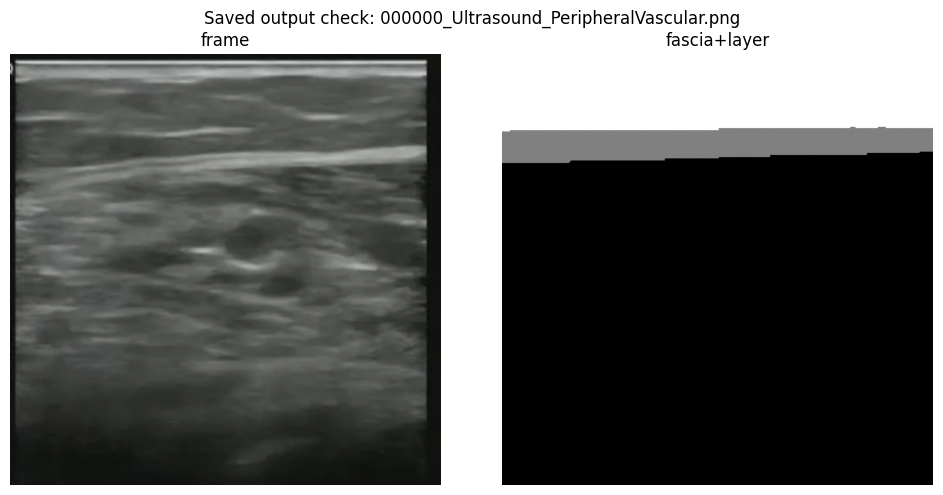

In [35]:
# â”€â”€ Quick sanity check: visualise one saved train pair â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
sample_img_path  = sorted((OUT_ROOT / 'train').glob('*.png'))[0]
sample_stem      = sample_img_path.stem
matching_masks   = list((OUT_ROOT / 'train_mask').glob(f"{sample_stem}_*.png"))

fig, axes = plt.subplots(1, 1 + len(matching_masks), figsize=(5 * (1 + len(matching_masks)), 5))
axes[0].imshow(np.array(Image.open(sample_img_path)))
axes[0].set_title('frame')
axes[0].axis('off')
for i, mp in enumerate(matching_masks):
    axes[i+1].imshow(np.array(Image.open(mp)), cmap='gray')
    axes[i+1].set_title(mp.stem.split('_')[-1])
    axes[i+1].axis('off')
plt.suptitle(f"Saved output check: {sample_img_path.name}")
plt.tight_layout()
plt.show()

## 3 Â· Verify `label_base.json` Has New Categories

In [36]:
label_base_path = BIOMEDPARSE / 'biomedparse_datasets' / 'label_base.json'
with open(label_base_path) as f:
    label_base = json.load(f)

print("ID 17:", label_base.get('17'))
print("ID 18:", label_base.get('18'))

if '17' not in label_base or '18' not in label_base:
    print("\nAdding missing entries...")
    label_base['17'] = {
        'name': 'fascia layer',
        'parent': 'structure',
        'alternative name': ['fascia', 'fascial layer', 'hyperechoic fascial layer',
                              'connective tissue layer', 'fascial plane']
    }
    label_base['18'] = {
        'name': 'vein',
        'parent': 'vessel',
        'alternative name': ['vein', 'blood vessel', 'anechoic vessel']
    }
    with open(label_base_path, 'w') as f:
        json.dump(label_base, f, indent=2)
    print("Done.")
else:
    print("\nBoth categories already present.")

ID 17: {'name': 'fascia layer', 'parent': 'structure', 'alternative name': ['fascia', 'fascial layer', 'hyperechoic fascial layer', 'connective tissue layer', 'fascial plane']}
ID 18: {'name': 'vein', 'parent': 'vessel', 'alternative name': ['vein', 'blood vessel', 'anechoic vessel']}

Both categories already present.


## 4 Â· Generate COCO JSON Annotations

Replicates `create-customer-datasets.py` logic inline so you can see what's happening and inspect the output.

In [37]:
# â”€â”€ Build parent_class and category_ids from label_base â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
parent_class = {}
for i in label_base:
    subnames = [label_base[i]['name']] + label_base[i].get('child', [])
    for label in subnames:
        parent_class[label] = int(i)

category_ids = {label_base[i]['name']: int(i) for i in label_base if 'name' in label_base[i]}

print("'fascia layer' â†’ category_id:", parent_class.get('fascia layer', 'MISSING'))
print("'vein'         â†’ category_id:", parent_class.get('vein', 'MISSING'))

'fascia layer' â†’ category_id: 17
'vein'         â†’ category_id: 18


In [38]:
def make_coco_categories(category_ids):
    return [{'supercategory': k, 'id': v, 'name': k} for k, v in category_ids.items()]

def make_coco_image(file_name, image_id, size=1024):
    return {'file_name': file_name, 'height': size, 'width': size, 'id': image_id}

def build_annotations(split: str):
    mask_root  = OUT_ROOT / f"{split}_mask"
    image_root = OUT_ROOT / split

    images, annotations = [], []
    image_to_id  = {}
    annotation_id = 0
    sent_id = 0
    ref_id  = 0
    errors  = 0

    mask_files = sorted(mask_root.glob('*.png'))
    for mask_path in tqdm(mask_files, desc=f'annotating {split}'):
        parts = mask_path.stem.split('_')
        target_name = parts[-1].replace('+', ' ')   # 'fascia+layer' â†’ 'fascia layer'
        orig_name   = '_'.join(parts[:-1]) + '.png'

        if not (image_root / orig_name).exists():
            print(f"  missing image: {orig_name}")
            errors += 1
            continue

        if orig_name not in image_to_id:
            iid = len(image_to_id)
            image_to_id[orig_name] = iid
            images.append(make_coco_image(orig_name, iid))

        iid = image_to_id[orig_name]

        # BiomedParse expects 'sentences' (grounding refs) on each annotation
        mod  = orig_name.split('.')[0].split('_')[-2]    # 'Ultrasound'
        site = orig_name.split('.')[0].split('_')[-1]    # 'PeripheralVascular'
        prompt = f"{target_name} in {site} {mod}"

        ann = {
            'mask_file':   mask_path.name,
            'iscrowd':     0,
            'image_id':    iid,
            'category_id': parent_class[target_name],
            'id':          annotation_id,
            'file_name':   orig_name,
            'split':       split,
            'sentences':   [{'raw': prompt, 'sent': prompt, 'sent_id': sent_id}],
            'sent_ids':    [sent_id],
            'ann_id':      annotation_id,
            'ref_id':      ref_id,
        }
        annotations.append(ann)
        annotation_id += 1
        sent_id += 1
        ref_id  += 1

    # Drop images with no annotations
    annotated_files = {a['file_name'] for a in annotations}
    images = [im for im in images if im['file_name'] in annotated_files]

    print(f"  {split}: {len(images)} images, {len(annotations)} annotations, {errors} errors")
    return images, annotations


for split in ['train', 'test']:
    imgs, anns = build_annotations(split)
    coco = {
        'info': {},
        'licenses': [],
        'images':      imgs,
        'categories':  make_coco_categories(category_ids),
        'annotations': anns,
    }
    out_json = OUT_ROOT / f"{split}.json"
    with open(out_json, 'w') as f:
        json.dump(coco, f)
    print(f"  Written: {out_json}")

annotating train: 100%|██████████| 10496/10496 [00:00<00:00, 83227.93it/s]


  train: 9020 images, 10496 annotations, 0 errors
  Written: C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\train.json


annotating test: 100%|██████████| 768/768 [00:00<00:00, 96110.08it/s]

  test: 768 images, 768 annotations, 0 errors
  Written: C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\BiomedParse\biomedparse_datasets\Fascia_Detection\test.json


In [39]:
# Inspect a few annotation entries 
with open(OUT_ROOT / 'train.json') as f:
    train_json = json.load(f)

print("Train JSON keys:", list(train_json.keys()))
print("\nFirst annotation:")
print(json.dumps(train_json['annotations'][0], indent=2))
print("\nCategory sample:")
print(json.dumps([c for c in train_json['categories'] if c['id'] in (17, 18)], indent=2))

Train JSON keys: ['info', 'licenses', 'images', 'categories', 'annotations']

First annotation:
{
  "mask_file": "000000_Ultrasound_PeripheralVascular_fascia+layer.png",
  "iscrowd": 0,
  "image_id": 0,
  "category_id": 17,
  "id": 0,
  "file_name": "000000_Ultrasound_PeripheralVascular.png",
  "split": "train",
  "sentences": [
    {
      "raw": "fascia layer in PeripheralVascular Ultrasound",
      "sent": "fascia layer in PeripheralVascular Ultrasound",
      "sent_id": 0
    }
  ],
  "sent_ids": [
    0
  ],
  "ann_id": 0,
  "ref_id": 0
}

Category sample:
[
  {
    "supercategory": "fascia layer",
    "id": 17,
    "name": "fascia layer"
  },
  {
    "supercategory": "vein",
    "id": 18,
    "name": "vein"
  }
]


## 5 Â· Fine-Tuning

Training runs via `mpirun` / `entry.py`. We launch it as a subprocess from here.

> **GPU memory**: batch_size=4 at 1024Ã—1024 needs ~22 GB VRAM (RTX 5090 has 32 GB â€” fine).
> Training ~4,800 frames Ã— 20 epochs takes â‰ˆ 2â€“4 hours.

Checkpoints land in `BiomedParse/output/fascia_finetuning/`.

In [40]:
import subprocess, re, sys
from tqdm.std import tqdm as _tqdm

train_env = os.environ.copy()
train_env['PYTHONPATH'] = str(BASE_DIR / 'stubs') + os.pathsep + str(BIOMEDPARSE) + os.pathsep + train_env.get('PYTHONPATH', '')
train_env.update({
    'DETECTRON2_DATASETS': str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep,
    'DATASET':             str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep,
    'DATASET2':            str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep,
    'VLDATASET':           str(BIOMEDPARSE / 'biomedparse_datasets') + os.sep,
    'OMPI_ALLOW_RUN_AS_ROOT':         '1',
    'OMPI_ALLOW_RUN_AS_ROOT_CONFIRM': '1',
    'PYTHONWARNINGS':               'ignore',
    'PYTORCH_CUDA_ALLOC_CONF':      'expandable_segments:True',
})

cmd = [
    sys.executable, 'entry.py', 'train',
    '--conf_files', 'configs/biomed_fascia_finetuning.yaml',
    '--overrides',
    'FP16', 'True',
    'RANDOM_SEED', '2024',
    'BioMed.INPUT.IMAGE_SIZE', '512',
    'MODEL.DECODER.HIDDEN_DIM', '512',
    'MODEL.ENCODER.CONVS_DIM', '512',
    'MODEL.ENCODER.MASK_DIM', '512',
    'TEST.BATCH_SIZE_TOTAL', '2',
    'TRAIN.BATCH_SIZE_TOTAL', '2',
    'TRAIN.BATCH_SIZE_PER_GPU', '2',
    'SOLVER.MAX_NUM_EPOCHS', '5',
    'SOLVER.BASE_LR', '0.00001',
    'SOLVER.FIX_PARAM.backbone', 'True',
    'SOLVER.FIX_PARAM.lang_encoder', 'True',
    'SOLVER.FIX_PARAM.pixel_decoder', 'False',   # UNFROZEN — must learn ultrasound features
    'MODEL.DECODER.COST_SPATIAL.CLASS_WEIGHT', '1.0',
    'MODEL.DECODER.COST_SPATIAL.MASK_WEIGHT',  '1.0',
    'MODEL.DECODER.COST_SPATIAL.DICE_WEIGHT',  '1.0',
    'MODEL.DECODER.TOP_SPATIAL_LAYERS', '10',
    'MODEL.DECODER.SPATIAL.ENABLED', 'True',
    'MODEL.DECODER.GROUNDING.ENABLED', 'True',
    'MODEL.DECODER.SPATIAL.MAX_ITER', '0',
    'LOADER.SAMPLE_PROB', 'prop',
    'BioMed.INPUT.RANDOM_ROTATE', 'True',
    'FIND_UNUSED_PARAMETERS', 'True',
    'ATTENTION_ARCH.SPATIAL_MEMORIES', '32',
    'ATTENTION_ARCH.QUERY_NUMBER', '3',
    'STROKE_SAMPLER.MAX_CANDIDATE', '10',
    'WEIGHT', 'True',
    'RESUME_FROM', str(BASE_DIR / 'pretrained' / 'biomedparse_v1.pt'),
    'SAVE_DIR', 'output/fascia_finetuning_v2',
]

_NOISE = (
    'utilities.model:Loaded',
    'FutureWarning',
    'UserWarning',
    'warnings.warn(',
    'Deformable Transformer Encoder is not available',
    'timm.models.layers',
    'non-tuple sequence for multidimensional',
    'torch.cuda.amp.autocast(args...)',
    'interpreted as tensor index',
    'Triggered internally at',
)

print("Starting fine-tuning  [512px | batch=2 | 5 epochs | backbone+lang frozen | pixel_decoder TRAINABLE]")
print()

proc = subprocess.Popen(
    cmd,
    cwd=str(BIOMEDPARSE),
    env=train_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

total_epochs  = 5
total_batches = None
current_epoch = -1
epoch_bar     = None
batch_bar     = None

BAR_FMT_EPOCH = '{desc}: {bar:30} {n_fmt}/{total_fmt} epochs  [{elapsed}<{remaining}]'
BAR_FMT_BATCH = '{desc}: {bar:30} {n_fmt}/{total_fmt} batches [{elapsed}<{remaining}]  {postfix}'

def _log(msg):
    _tqdm.write(msg, file=sys.stdout)

try:
    for line in proc.stdout:
        s = line.rstrip()
        if any(p in s for p in _NOISE):
            continue

        m = re.search(r'Num Epochs\s*=\s*(\d+)', s)
        if m:
            total_epochs = int(m.group(1))
            _log(s)
            continue

        m = re.search(r'Num of Mini Batches per Epoch\s*=\s*(\d+)', s)
        if m:
            total_batches = int(m.group(1))
            epoch_bar = _tqdm(total=total_epochs, desc='Overall',
                              bar_format=BAR_FMT_EPOCH,
                              position=0, leave=True, file=sys.stdout)
            _log(s)
            continue

        m = re.search(r'Start epoch:\s*(\d+)\s*training', s)
        if m:
            current_epoch = int(m.group(1))
            if batch_bar:
                batch_bar.close()
            if total_batches:
                batch_bar = _tqdm(total=total_batches,
                                  desc=f'Epoch {current_epoch+1}/{total_epochs}',
                                  bar_format=BAR_FMT_BATCH,
                                  position=1, leave=False, file=sys.stdout)
            continue

        m = re.search(r'optim steps\[(\S+)\].*?train loss\[(.+?)\]\s+epoch remaining\[(.+?)\]', s)
        if m:
            opt_step  = int(float(m.group(1)))
            loss_str  = m.group(2)
            eta       = m.group(3)
            if batch_bar and total_batches:
                batch_in_epoch = opt_step - current_epoch * total_batches
                delta = max(0, batch_in_epoch - batch_bar.n)
                if delta > 0:
                    batch_bar.update(delta)
                batch_bar.set_postfix_str(f'loss: {loss_str}  ETA {eta}', refresh=True)
            continue

        if 'This epoch takes' in s:
            if batch_bar:
                remaining = (total_batches or 0) - batch_bar.n
                if remaining > 0:
                    batch_bar.update(remaining)
                batch_bar.close()
                batch_bar = None
            if epoch_bar:
                epoch_bar.update(1)
            _log(s)
            continue

        _log(s)

except KeyboardInterrupt:
    proc.terminate()
    _log('\nTraining interrupted.')
finally:
    if batch_bar:
        batch_bar.close()
    if epoch_bar:
        epoch_bar.close()

proc.wait()
print(f'\nProcess exited with code {proc.returncode}')


Starting fine-tuning  [512px | batch=2 | 5 epochs | backbone+lang frozen | pixel_decoder TRAINABLE]

Random seed set as 2024
INFO:trainer.distributed_trainer:Setting SAVE_DIR as output\fascia_finetuning_v2
INFO:trainer.distributed_trainer:Using CUDA
INFO:trainer.distributed_trainer:Save config file to output\fascia_finetuning_v2\conf_copy.yaml
INFO:trainer.distributed_trainer:Base learning rate: 1e-05
INFO:trainer.distributed_trainer:Number of GPUs: 1
INFO:trainer.distributed_trainer:Gradient accumulation steps: 1
INFO:trainer.default_trainer:Imported base_dir at base_path ./
INFO:trainer.default_trainer:Pipeline for training: XDecoderPipeline
C:\Users\Krish\Downloads\Cygnus_Med_Demo\VLM_Fascia_Detection\pretrained\biomedparse_v1.pt
INFO:trainer.default_trainer:-------------------------------------------------------
INFO:trainer.default_trainer:Training on rank: 0
INFO:httpx:HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/tokenizer_config.json "HTTP/

: 

## 6 Â· Inference with the Fine-Tuned Model

After training completes, replace `FINETUNED_WEIGHTS` with the actual checkpoint path.

In [ ]:
from torchvision import transforms
from modeling.BaseModel import BaseModel
from modeling import build_model
from modeling.language.loss import vl_similarity
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES

# â”€â”€ Find the latest checkpoint â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ckpt_dir = BIOMEDPARSE / 'output' / 'fascia_finetuning_v2'
ckpts = sorted(ckpt_dir.glob('**/model_state_dict.pt'), key=lambda p: p.stat().st_mtime)
if ckpts:
    FINETUNED_WEIGHTS = str(ckpts[-1])
    print(f"Found checkpoint: {FINETUNED_WEIGHTS}")
else:
    # Fall back to pretrained if fine-tuning not done yet
    FINETUNED_WEIGHTS = str(BASE_DIR / 'pretrained' / 'biomedparse_v1.pt')
    print(f"No fine-tuned checkpoint found â€” using pretrained: {FINETUNED_WEIGHTS}")

print()
print("Loading model...")
opt = load_opt_from_config_files([str(BIOMEDPARSE / 'configs' / 'biomedparse_inference.yaml')])
opt = init_distributed(opt)

model = BaseModel(opt, build_model(opt)).from_pretrained(FINETUNED_WEIGHTS).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(
        BIOMED_CLASSES + ['background'], is_eval=True
    )
print("Model loaded.")

_img_transform = transforms.Compose([
    transforms.Resize((1024, 1024), interpolation=Image.BICUBIC)
])


In [ ]:
# â”€â”€ Inference helpers (mirrors app.py) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def _img_to_tensor(pil_image):
    resized = _img_transform(pil_image)
    arr = np.asarray(resized).copy()
    return torch.from_numpy(arr).permute(2, 0, 1).cuda()


@torch.no_grad()
def vlm_text_infer_prob(query_image_pil, text_prompts):
    img_tensor = _img_to_tensor(query_image_pil)
    W, H = query_image_pil.size
    model.model.task_switch.update({'spatial': False, 'visual': False, 'grounding': True, 'audio': False})

    data = {'image': img_tensor, 'text': text_prompts, 'height': H, 'width': W}
    results, _, extra = model.model.evaluate_demo([data])

    pred_masks = results['pred_masks'][0]
    v_emb = results['pred_captions'][0]
    t_emb = extra['grounding_class']
    t_emb = t_emb / (t_emb.norm(dim=-1, keepdim=True) + 1e-7)
    v_emb = v_emb / (v_emb.norm(dim=-1, keepdim=True) + 1e-7)

    temperature = model.model.sem_seg_head.predictor.lang_encoder.logit_scale
    out_prob = vl_similarity(v_emb, t_emb, temperature=temperature)
    matched_ids = out_prob.max(0)[1]

    best_prob = np.zeros((H, W), dtype=np.float32)
    for idx in matched_ids:
        prob = F.interpolate(
            pred_masks[idx:idx+1][None], (H, W), mode='bilinear'
        )[0, 0, :H, :W].sigmoid().cpu().numpy()
        best_prob = np.maximum(best_prob, prob.astype(np.float32))
    return best_prob


def prob_to_fascia_centreline(prob, threshold=0.15):
    H, W = prob.shape
    centreline = np.zeros((H, W), dtype=np.uint8)
    valid_cols, y_vals = [], []
    for col in range(W):
        col_p = prob[:, col]
        if col_p.max() > threshold:
            valid_cols.append(col)
            y_vals.append(float(np.argmax(col_p)))
    if len(valid_cols) < 0.40 * W:
        return centreline
    y_arr = np.array(y_vals, dtype=np.float32)
    k = min(31, len(y_arr))
    if k >= 3:
        y_arr = np.convolve(y_arr, np.ones(k) / k, mode='same')
    keep = np.ones(len(y_arr), dtype=bool)
    for i in range(1, len(y_arr)):
        if abs(y_arr[i] - y_arr[i-1]) > 8:
            keep[i] = False
    for i, col in enumerate(valid_cols):
        if keep[i]:
            centreline[int(y_arr[i]), col] = 255
    h_close = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 1))
    centreline = cv2.morphologyEx(centreline, cv2.MORPH_CLOSE, h_close)
    v_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
    return cv2.dilate(centreline, v_dilate, iterations=1)


def annotate(image_rgb, vein_mask, fascia_mask):
    out = image_rgb.copy()
    FASCIA_COLOR = (0, 210, 210)
    VEIN_COLOR   = (0, 210, 0)
    if fascia_mask is not None and fascia_mask.max() > 0:
        out[fascia_mask > 0] = FASCIA_COLOR
    if vein_mask is not None and vein_mask.max() > 0:
        cnts, _ = cv2.findContours(vein_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, cnts, -1, VEIN_COLOR, 3)
    return out

In [ ]:
# â”€â”€ Run inference on 6 test frames and display results â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test_frames = sorted((OUT_ROOT / 'test').glob('*.png'))[:6]
print(f"Running inference on {len(test_frames)} test frames...")

FASCIA_PROMPTS = [
    'fascia layer', 'fascial layer',
    'hyperechoic fascial layer',
    'connective tissue layer',
    'fascial plane in PeripheralVascular Ultrasound',
]
VEIN_PROMPTS = [
    'vein', 'blood vessel',
    'anechoic vessel in PeripheralVascular Ultrasound',
]

fig, axes = plt.subplots(len(test_frames), 3, figsize=(15, 5 * len(test_frames)))
if len(test_frames) == 1:
    axes = [axes]

for row_i, frame_path in enumerate(test_frames):
    image = Image.open(frame_path).convert('RGB')
    image_np = np.array(image)

    fascia_prob  = vlm_text_infer_prob(image, FASCIA_PROMPTS)
    vein_prob    = vlm_text_infer_prob(image, VEIN_PROMPTS)

    fascia_mask = prob_to_fascia_centreline(fascia_prob, threshold=0.15)
    vein_mask   = (vein_prob > 0.40).astype(np.uint8)

    annotated = annotate(image_np, vein_mask, fascia_mask)

    axes[row_i][0].imshow(image_np);         axes[row_i][0].set_title('Input');         axes[row_i][0].axis('off')
    axes[row_i][1].imshow(fascia_prob, cmap='hot', vmin=0, vmax=1); axes[row_i][1].set_title('Fascia prob'); axes[row_i][1].axis('off')
    axes[row_i][2].imshow(annotated);        axes[row_i][2].set_title('Annotated');      axes[row_i][2].axis('off')

    plt.colorbar(axes[row_i][1].images[0], ax=axes[row_i][1], fraction=0.046, pad=0.04)

fascia_patch = mpatches.Patch(color=(0, 210/255, 210/255), label='Fascia')
vein_patch   = mpatches.Patch(color=(0, 210/255, 0),       label='Vein')
fig.legend(handles=[fascia_patch, vein_patch], loc='upper right', fontsize=12)
plt.suptitle('Fine-tuned BiomedParse â€” Test Frame Inference', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# â”€â”€ Quick IoU evaluation on test set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test_mask_dir = OUT_ROOT / 'test_mask'
fascia_iou_list, vein_iou_list = [], []

for frame_path in tqdm(list((OUT_ROOT / 'test').glob('*.png'))[:50], desc='eval'):
    stem  = frame_path.stem
    image = Image.open(frame_path).convert('RGB')
    H, W  = image.size[1], image.size[0]

    fascia_gt_path = test_mask_dir / f"{stem}_fascia+layer.png"
    vein_gt_path   = test_mask_dir / f"{stem}_vein.png"

    if fascia_gt_path.exists():
        gt = (np.array(Image.open(fascia_gt_path).convert('L')) > 127).astype(np.uint8)
        prob = vlm_text_infer_prob(image, FASCIA_PROMPTS)
        pred = (prob > 0.15).astype(np.uint8)
        inter = (pred & gt).sum(); union = (pred | gt).sum()
        if union > 0:
            fascia_iou_list.append(inter / union)

    if vein_gt_path.exists():
        gt = (np.array(Image.open(vein_gt_path).convert('L')) > 127).astype(np.uint8)
        prob = vlm_text_infer_prob(image, VEIN_PROMPTS)
        pred = (prob > 0.40).astype(np.uint8)
        inter = (pred & gt).sum(); union = (pred | gt).sum()
        if union > 0:
            vein_iou_list.append(inter / union)

print(f"Fascia IoU (n={len(fascia_iou_list)}): {np.mean(fascia_iou_list):.3f}")
print(f"Vein   IoU (n={len(vein_iou_list)}):   {np.mean(vein_iou_list):.3f}")

## 7 Â· Update `app.py` to Use Fine-Tuned Weights

After confirming the model is working well above, point `app.py` at the new checkpoint.
Replace the single line that sets `pretrained_source`:

In [ ]:
import re

app_path = BASE_DIR / 'app.py'
src = app_path.read_text()

# Find the latest fine-tuned checkpoint
ckpts = sorted((BIOMEDPARSE / 'output' / 'fascia_finetuning').glob('**/*.pt'),
               key=lambda p: p.stat().st_mtime)
if not ckpts:
    print("No fine-tuned checkpoint found yet â€” run Section 5 first.")
else:
    ft_ckpt = ckpts[-1]
    print(f"Latest checkpoint: {ft_ckpt}")
    
    # Preview the line we're changing
    for line in src.splitlines():
        if 'pretrained_source' in line:
            print("Current:", line.strip())
    
    # Swap in fine-tuned weights as primary, keep HF hub as fallback
    new_src = re.sub(
        r"pretrained_source = LOCAL_WEIGHTS if os\.path\.exists\(LOCAL_WEIGHTS\) else 'hf_hub:microsoft/BiomedParse'",
        f"pretrained_source = r'{ft_ckpt}'  # fine-tuned on peripheral vascular ultrasound",
        src
    )
    if new_src == src:
        print("Pattern not matched â€” update app.py manually.")
    else:
        app_path.write_text(new_src)
        print("app.py updated â€” restart the Flask server to pick up new weights.")